# Importing the files and data used

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # 0 = all, 1 = INFO, 2 = WARNING, 3 = ERROR

In [40]:
from lstm import *
from sarima import *
from preprocessing import *
import json

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Data from Seine aval (SAV)
df_sav = SAV_preprocessing()

# Rainfall data
df_pluvio = rainfall_preprocessing()

# Data from Seine centre (SEC)
df_sec = SEC_preprocessing()

# SEC flow
debit_sec = SEC_flow_preprocessing()

## Construction of the training, validation, and test datasets

In [5]:
# Training set
df_train = X_construction(start = '2022-11-25 07:00:00',
                          end = '2023-11-24 06:45:00',
                          df_sav = df_sav,
                          debit_sec = debit_sec,
                          df_sec = df_sec,
                          df_pluvio = df_pluvio) # 1 year

# Validation sets
df_val1 = X_construction(start = '2023-11-24 07:00:00',
                        end = '2023-12-23 06:45:00',
                        df_sav = df_sav,
                        debit_sec = debit_sec,
                        df_sec = df_sec,
                        df_pluvio = df_pluvio) # 1 month in winter

df_val2 = X_construction(start = '2024-03-15 00:00:00',
                    end = '2024-04-14 23:45:00',
                    df_sav = df_sav,
                    debit_sec = debit_sec,
                    df_sec = df_sec,
                    df_pluvio = df_pluvio) # 1 month in spring

df_val3 = X_construction(start = '2024-07-01 00:00:00',
                         end = '2024-07-31 23:45:00', 
                        df_sav = df_sav,
                        debit_sec = debit_sec,
                        df_sec = df_sec,
                        df_pluvio = df_pluvio) # 1 month in summer

df_val4 = X_construction(start = '2024-09-01 00:00:00',
                        end = '2024-09-30 23:45:00',
                        df_sav = df_sav,
                        debit_sec = debit_sec,
                        df_sec = df_sec,
                        df_pluvio = df_pluvio) # 1 month in fall

# Test set used in article
df_test_1j = X_construction(start = '2023-12-07 20:00:00', 
                            end = '2023-12-08 19:45:00',
                            df_sav = df_sav,
                            debit_sec = debit_sec,
                            df_sec = df_sec,
                            df_pluvio = df_pluvio) # 1 day


## Training set for SARIMA models 

begin_test_index = df_sav.index.get_loc("2023-12-07 20:00:00")

df_train_10j = df_sav.iloc[begin_test_index - 96*10 : begin_test_index] # 10 days
df_train_10j.index = pd.DatetimeIndex(df_train_10j.index.values, freq = df_train_10j.index.inferred_freq)

# LSTM with exogenous variables
## Data transformation

In [6]:
# a and b represent the endpoints of the interval to which the data will belong
scaler = MinMaxScaler(feature_range = (a, b)) # a, b = -1, 1

df_train = pd.DataFrame(scaler.fit_transform(df_train),
                               columns = df_train.columns,
                               index = df_train.index)

df_val1 = pd.DataFrame(scaler.transform(df_val1),
                      columns = df_val1.columns,
                      index = df_val1.index)

df_val2 = pd.DataFrame(scaler.transform(df_val2),
                      columns = df_val2.columns,
                      index = df_val2.index)

df_val3 = pd.DataFrame(scaler.transform(df_val3),
                      columns = df_val3.columns,
                      index = df_val3.index)

df_val4 = pd.DataFrame(scaler.transform(df_val4),
                      columns = df_val4.columns,
                      index = df_val4.index)

df_val_list = [df_val1, df_val2, df_val3, df_val4]

## Grid search to find the best hyperparameters

This code may take a long time to run, depending on your computer's resources. To run it, simply execute the `grid_search_lstm.py` file, which is located in the same folder as this file.  
The results are as follows:

In [ ]:
with open("All_models/best_lstm_hyperparameters.json", "r") as f:
    best_hp = json.load(f)

print(best_hp)

## LSTM Model 

In [11]:
# Dataset for LSTM
train, valid = multi_train_valid(df_train, df_val_list)

# Data used in the input of LSTM model for Test set
tests_multi_1j = build_multi_test_sets(first_end_date = '2023-12-07 19:45:00',
                                scaler = scaler,
                                df_sav = df_sav,
                                debit_sec = debit_sec, 
                                df_sec = df_sec,
                                df_pluvio = df_pluvio,
                                n_days = 1) 

In [ ]:
"""
This code can take a long time to run, depending on the computer; 
you can skip it and use the settings stored in the next cell.
"""
# Best model with exogenous variables
lstm_multi = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape = (960, 12)),
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(h * 4),
    tf.keras.layers.Reshape((h, 4))
])

history_multi, result_multi = fit_and_evaluate(lstm_multi, train, valid, 
                                               learning_rate = 0.001, patience = 3)
print(result_multi)

In [18]:
# To save the model settings
lstm_multi.save_weights("All_models/model_lstm.weights.h5")  

In [ ]:
# Reconstruct the model that had been saved
lstm_multi = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape = (960, 12)),
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(h * 4),
    tf.keras.layers.Reshape((h, 4))
])

lstm_multi.load_weights("All_models/model_lstm.weights.h5")

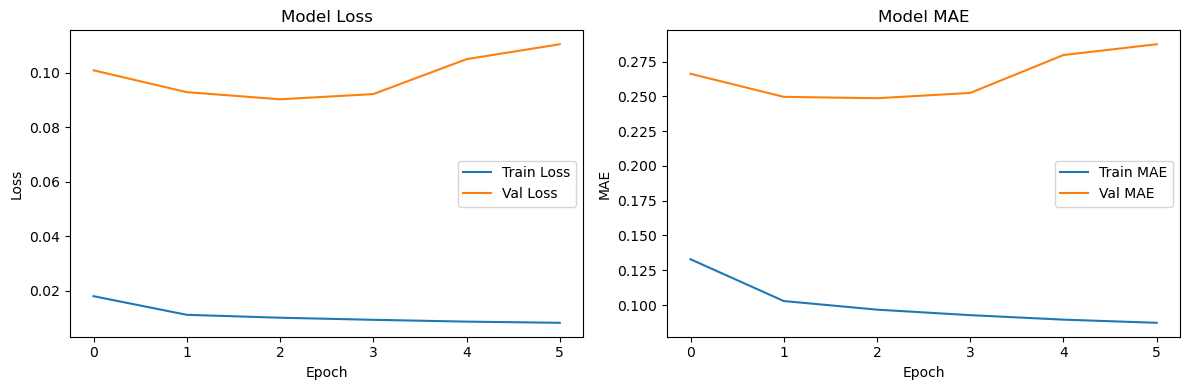

In [32]:
plot_training_history(history_multi)

# Forecasting with all models

## Reconstruction of the SARIMA models that had been saved

In [34]:
# Conductivity
results_condu = load_sarima_params(df_train_10j["Conductivity SAV"], 
                                   "All_models/best_model_condu.json")

# pH
results_ph = load_sarima_params(df_train_10j["pH SAV"], 
                                   "All_models/best_model_ph.json")

# Temperature
results_temp = load_sarima_params(df_train_10j["Temperature SAV"], 
                                   "All_models/best_model_temp.json")

# TSS
results_mes = load_sarima_params(df_train_10j["TSS SAV"], 
                                   "All_models/best_model_tss.json")

## Forecasting

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


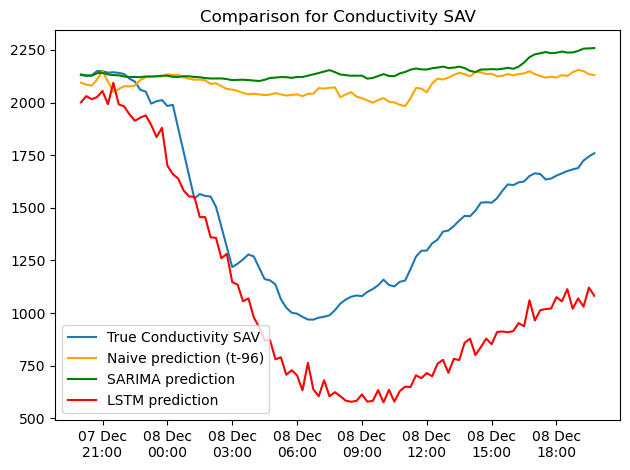


===== Errors for Conductivity SAV =====

Naive model:
MAE test : 602.0562252468534
MAPE test : 48.17564053160361 %

LSTM model:
MAE test : 399.4099227474741
MAPE test : 28.98146298343265 %

SARIMA model:
MAE test : 656.1956255066767
MAPE test : 52.61133507948998 %


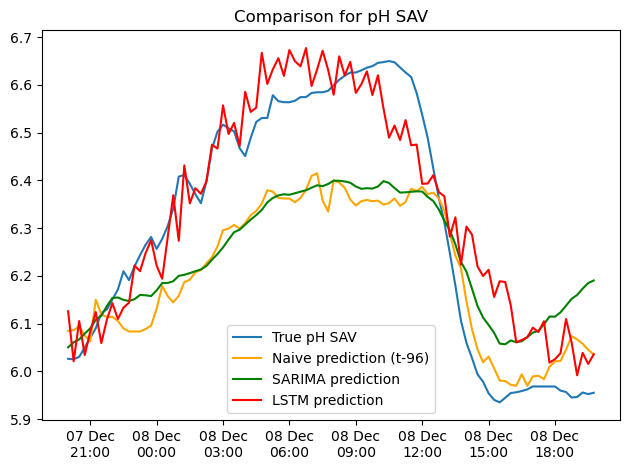


===== Errors for pH SAV =====

Naive model:
MAE test : 0.1400146385420252
MAPE test : 2.1747216126036824 %

LSTM model:
MAE test : 0.07872930310568546
MAPE test : 1.2663849390819728 %

SARIMA model:
MAE test : 0.15330858587637805
MAPE test : 2.4077276204975 %


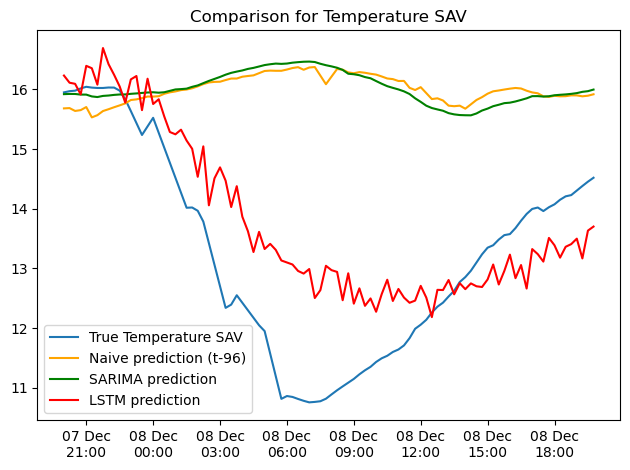


===== Errors for Temperature SAV =====

Naive model:
MAE test : 2.8721658833821615
MAPE test : 23.788501476200473 %

LSTM model:
MAE test : 0.9386475698506396
MAPE test : 7.665127434511869 %

SARIMA model:
MAE test : 2.8267876257186746
MAPE test : 23.48839268429815 %


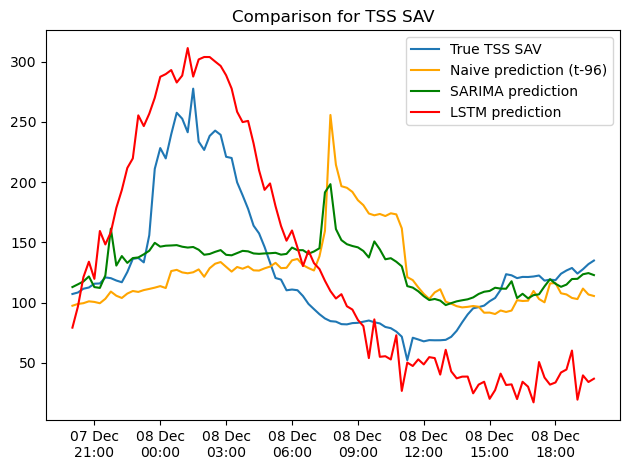


===== Errors for TSS SAV =====

Naive model:
MAE test : 49.901812065972216
MAPE test : 42.93538069224965 %

LSTM model:
MAE test : 51.84749773046892
MAPE test : 41.692259126598955 %

SARIMA model:
MAE test : 38.29084009537111
MAPE test : 32.679444945287045 %


In [42]:
sarima_models = {
    "Conductivity SAV": results_condu,
    "pH SAV": results_ph,
    "Temperature SAV": results_temp,
    "TSS SAV": results_mes
}

# all_errors is a dataframe which contains all models errors
all_errors = plot_compare_models(lstm_model = lstm_multi,
                    sarima_models = sarima_models,
                    tests = tests_multi_1j, 
                    cols = df_train.columns[:4],
                    scaler = scaler,
                    df_test = df_test_1j,
                    df_sav = df_sav, lag = 96)

In [44]:
all_errors

,Variable,Persistence_MAE,Persistence_MAPE,SARIMA_MAE,SARIMA_MAPE,LSTM_MAE,LSTM_MAPE
0,Conductivity SAV,602.056225,48.175641,656.195626,52.611335,399.409923,28.981463
1,pH SAV,0.140015,2.174722,0.153309,2.407728,0.078729,1.266385
2,Temperature SAV,2.872166,23.788501,2.826788,23.488393,0.938648,7.665127
3,TSS SAV,49.901812,42.935381,38.290840,32.679445,51.847498,41.692259
